# Time Series Momentum Trading with Python

#### Objectives:
    * If assets was rising by 5% over the last 20 days, hold it for 5 days ans sell it

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
import yfinance as yf 
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.filterwarnings('ignore') 

In [2]:
df = yf.download('AAPL', start='2020-01-01',end='2024-05-01')
df.head() 

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960449,135480400
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251160,146322800
2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826851,118387200
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484329,108872000
2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200


In [3]:
df['return_20'] = df['Close'].pct_change(20)  # rolling 20 day return
df.dropna(inplace=True) 
df.head() 

,Open,High,Low,Close,Adj Close,Volume,return_20
Date,,,,,,,
2020-01-31,80.232498,80.669998,77.072502,77.377502,75.185577,199588400,0.030498
2020-02-03,76.074997,78.372498,75.555000,77.165001,74.979118,173788400,0.037757
2020-02-04,78.827499,79.910004,78.407501,79.712502,77.454445,136616400,0.063542
2020-02-05,80.879997,81.190002,79.737503,80.362503,78.086044,118826800,0.077281
2020-02-06,80.642502,81.305000,80.065002,81.302498,78.999397,105425600,0.072628


In [4]:
df['signal'] = df['return_20']>0.05 
df.head() 

,Open,High,Low,Close,Adj Close,Volume,return_20,signal
Date,,,,,,,,
2020-01-31,80.232498,80.669998,77.072502,77.377502,75.185577,199588400,0.030498,0
2020-02-03,76.074997,78.372498,75.555000,77.165001,74.979118,173788400,0.037757,0
2020-02-04,78.827499,79.910004,78.407501,79.712502,77.454445,136616400,0.063542,1
2020-02-05,80.879997,81.190002,79.737503,80.362503,78.086044,118826800,0.077281,1
2020-02-06,80.642502,81.305000,80.065002,81.302498,78.999397,105425600,0.072628,1


In [5]:
df['buy_price'] = df['Open'].shift(-1) 
df.head() 

,Open,High,Low,Close,Adj Close,Volume,return_20,signal,buy_price
Date,,,,,,,,,
2020-01-31,80.232498,80.669998,77.072502,77.377502,75.185577,199588400,0.030498,0,76.074997
2020-02-03,76.074997,78.372498,75.555000,77.165001,74.979118,173788400,0.037757,0,78.827499
2020-02-04,78.827499,79.910004,78.407501,79.712502,77.454445,136616400,0.063542,1,80.879997
2020-02-05,80.879997,81.190002,79.737503,80.362503,78.086044,118826800,0.077281,1,80.642502
2020-02-06,80.642502,81.305000,80.065002,81.302498,78.999397,105425600,0.072628,1,80.592499


In [6]:
profits = []
in_position = False 
sellidx = pd.to_datetime('1900-01-01') 

for index, row in df.iterrows():
    if not in_position and row.signal and index>sellidx:
        buyprice = df.loc[index:][0:1].buy_price.values[0]
        in_position = True 

    if in_position:
        sellprice = df.loc[index:][5:6].Close.values[0]   
        sellidx = df.loc[index:][5:6].index
        profit = (sellprice-buyprice)/buyprice
        profits.append(profit)
        in_position = False 

<Axes: >

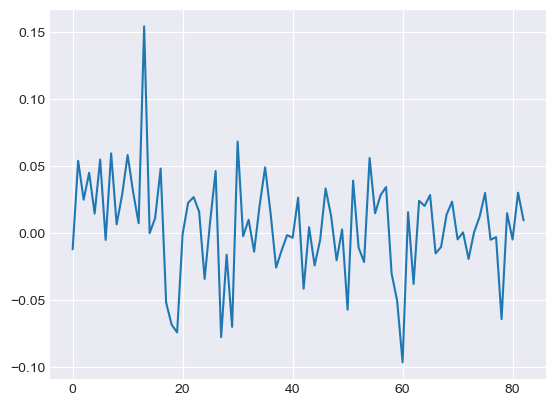

In [8]:
pd.Series(profits).plot() 

<Axes: >

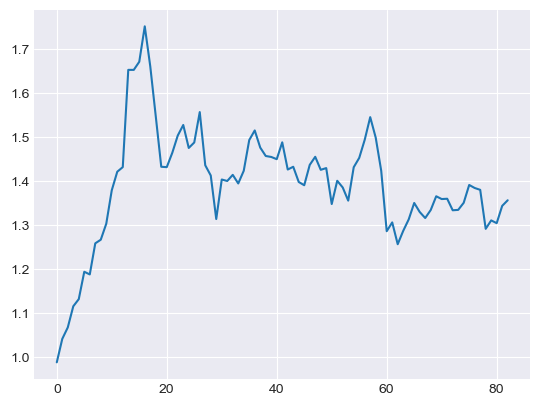

In [9]:
(pd.Series(profits)+1).cumprod().plot() 

In [13]:
print('Total profit made : ',(((pd.Series(profits)+1).prod() - 1)*100).round(2),'%') 

Total profit made :  35.63 %
